# Algebra lineal y sistemas de ecuaciones lineales

In [1]:
# Librerías utilizadas en este capítulo
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, det, inv, cond, matrix_rank
from pathlib import Path
from IPython.display import HTML

## Introducción a los sistemas de ecuaciones lineales

Consideremos el caso de tres cuerpos conectados por cuerdas elásticas.

<img src="./images/bungee_man.png" width="300" align= center>

En la primera figura (a), los tres cuerpos están en la posición inicial de forma que los elásticos están totalmente extendidos, **pero no estirados**. Definimos el cambio en la posición inicial de cada persona, como: $x_1$, $x_2$, $x_3$.

Cuando los cuerpos se dejan caer, los elásticos se extienden por la gravedad y cada cuerpo toma la posición indicada en (b).

Analizamos el cambio en la posición de cada persona utilizando la ley de Newton:

*Diagrama de cuerpo libre*

<img src="./images/bungee_man_solve.png" width="300" align= center>

\begin{align*}
m_1\frac{d^2 x_1}{dt^2} &= m_1g + k_2(x_2 - x_1) - k_1 x_1 \\
m_2\frac{d^2 x_2}{dt^2} &= m_2g + k_3(x_3 - x_2) - k_2 (x_2 - x_1) \\
m_3\frac{d^2 x_3}{dt^2} &= m_3g + k_3(x_2 - x_3)
\end{align*}

En cada ecuación, el término $k_i(x_j - x_i)$ representa la fuerza del elástico que conecta ambos cuerpos, y siempre se escribe como *(posición del otro extremo) $-$ (posición del cuerpo analizado)*.

En condiciones de equilibrio ($d^2x_i/dt^2 = 0$):

\begin{align*}
(k_1 + k_2)x_1\;\;\;\;\;\;\;\;\; - k_2x_2 \;\;\;\;\;\;\;\;\;\;\,&=  m_1g\\
- k_2x_1 + (k_2 + k_3)x_2 - k_3x_3  &= m_2g\\
- k_3x_2 + k_3x_3 &= m_3g
\end{align*}

Derivamos un **sistema de ecuaciones lineales** con 3 incógnitas, que podemos resolver con técnicas analíticas.

Sin embargo, si el sistema es más grande tenemos un gran número de incógnitas y debemos recurrir a métodos más eficientes.

Por ejemplo, un reticulado de barras, donde cada barra se puede modelar como un resorte.

<img src="./images/beam_lattice.png" width="800px" align= center>

Este es el enfoque que utilizan los software de modelación computacional, tales como: el método de elementos finitos (FEM), métodos de los momentos (MoM), o volúmenes finitos (VEM).

<img src="./images/fem_beam_lattice.png" width="600" align= center>

### Caracterización de sistemas lineales

Un **sistema de ecuaciones lineales** está compuesto por más de una ecuación lineal, tal como en el ejemplo de las personas conectadas por cuerdas elásticas.

Decimos que una ecuación es lineal cuando:
1. Cada término contiene **a lo más una** incógnita, elevada a la potencia $1$.
2. Los términos están conectados **únicamente** por sumas o restas.

Por ejemplo,
- $3x_1 + 4x_2 - 3 = -5x_3$ (lineal)

- $x_1 x_2 + x_3 = 5$ (no lineal: el término $x_1x_2$ tiene dos incógnitas)

- $x_1 + 3x_2 + x_3^4 = 3$ (no lineal: el exponente de $x_3$ no es 1)

Un caso intermedio:

$$\frac{-3x_1 + x_2}{x_3} = 2$$

no está escrita en forma lineal, pero **multiplicando por $x_3$** obtenemos la ecuación equivalente $-3x_1 + x_2 - 2x_3 = 0$, que sí lo está.

> Ojo con el vocabulario: esta es una **reescritura algebraica exacta**, válida solo si $x_3 \neq 0$. No es una *linealización* (aproximar una función no lineal por su recta tangente), concepto que veremos en ajuste de curvas y en el método de Newton.

### Representación matricial

Para resolver un sistema de ecuaciones lineales utilizamos la representación matricial. Esto permite la implementación computacional de los algoritmos.

Por ejemplo, el sistema de ecuaciones lineales generalizado:

$$
\begin{aligned}
\begin{array}{rcrcccccrcc}
a_{1,1} x_1 &+& a_{1,2} x_2 &+& {\ldots}& +& a_{1,n-1} x_{n-1} &+&a_{1,n} x_n &=& y_1,\\
a_{2,1} x_1 &+& a_{2,2} x_2 &+&{\ldots}& +& a_{2,n-1} x_{n-1} &+& a_{2,n} x_n &=& y_2, \\
&&&&{\ldots} &&{\ldots}&&&& \\
a_{m-1,1}x_1 &+& a_{m-1,2}x_2&+ &{\ldots}& +& a_{m-1,n-1} x_{n-1} &+& a_{m-1,n} x_n &=& y_{m-1},\\
a_{m,1} x_1 &+& a_{m,2}x_2 &+ &{\ldots}& +& a_{m,n-1} x_{n-1} &+& a_{m,n} x_n &=& y_{m}.
\end{array}
\end{aligned}
$$

donde $a_{i,j}$ y $y_i$ son números reales.

Toma la siguiente forma en su representación matricial

$$\begin{bmatrix}
a_{1,1} & a_{1,2} & ... & a_{1,n}\\
a_{2,1} & a_{2,2} & ... & a_{2,n}\\
... & ... & ... & ... \\
a_{m,1} & a_{m,2} & ... & a_{m,n}
\end{bmatrix}\left[\begin{array}{c} x_1 \\x_2 \\ ... \\x_n \end{array}\right] =
\left[\begin{array}{c} y_1 \\y_2 \\ ... \\y_m \end{array}\right]$$

O, similarmente,

$$Ax = y,$$

donde:

$$A = \begin{bmatrix}
a_{1,1} & a_{1,2} & ... & a_{1,n}\\
a_{2,1} & a_{2,2} & ... & a_{2,n}\\
... & ... & ... & ... \\
a_{m,1} & a_{m,2} & ... & a_{m,n}
\end{bmatrix},\;\;x= \left[\begin{array}{c} x_1 \\x_2 \\ ... \\x_n \end{array}\right],\;\;\ y = \left[\begin{array}{c} y_1 \\y_2 \\ ... \\y_m \end{array}\right]$$

De igual forma, el problema de las personas sujetas con elásticos se representa como:

$$\begin{bmatrix}
k_1 + k_2 & -k_2 & 0 \\
-k_2 & k_2 + k_3 & -k_3\\
0 & -k_3 & k_3
\end{bmatrix}
\left[\begin{array}{c} x_1 \\x_2 \\ x_3 \end{array}\right] =
\left[\begin{array}{c} m_1g \\m_2g \\m_3g \end{array}\right]$$

> Notar la **estructura** de la matriz: solo la diagonal y sus vecinos inmediatos son distintos de cero. Una matriz con esta forma se llama **tridiagonal**, aparece con mucha frecuencia en ingeniería, y admite métodos de solución mucho más económicos. Volveremos sobre ella en el resumen final del capítulo.

### Repaso de matrices

#### Determinante ($|A|$)
Se denota como $\mathrm{det}(A)$, o $|A|$. **Solo se aplica a matrices cuadradas**.

   Por ejemplo, para una matriz $2\times2$, el determinante es:

   $$ |A| = \begin{vmatrix} a & b \\
                             c & d\\
            \end{vmatrix} = ad - bc,$$

   para una matrix $3\times3$:

$$
\begin{aligned}
|A| = \begin{vmatrix}
a & b & c \\
d & e & f \\
g & h & i \\
\end{vmatrix} & = & a\begin{vmatrix}
\Box &\Box  &\Box  \\
\Box & e & f \\
\Box & h & i \\
\end{vmatrix} - b\begin{vmatrix}
\Box &\Box  &\Box  \\
d & \Box & f \\
g & \Box & i \\
\end{vmatrix}+c\begin{vmatrix}
\Box &\Box  &\Box  \\
d & e & \Box \\
g & h & \Box \\
\end{vmatrix} \\
&&\\
& = & a\begin{vmatrix}
e & f \\
h & i \\
\end{vmatrix} - b\begin{vmatrix}
d & f \\
g & i \\
\end{vmatrix}+c\begin{vmatrix}
d & e \\
g & h \\
\end{vmatrix} \\
&&\\
& = & aei - afh + bfg - bdi + cdh - ceg
\end{aligned}
$$

####  Matriz identidad ($I$)

Es una matriz cuadrada con $1$ en la diagonal, y $0$ en el resto de los elementos:

$$I = \begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
\end{bmatrix}$$

#### Matriz inversa ($A^{-1}$)

Definimos la matriz inversa de $A$ como: $A^{-1}$.

   - Solo existe para matrices cuadradas.

   - El producto de una matriz por su inversa es igual a la matriz identidad: $A\cdot A^{-1} = A^{-1}\cdot A = I$

   - Para una matriz $2\times2$, la matriz inversa está definida por:

   $$
A^{-1} = \begin{bmatrix}
a & b \\
c & d\\
\end{bmatrix}^{-1} = \frac{1}{|A|}\begin{bmatrix}
d & -b \\
-c & a\\
\end{bmatrix}$$

>La solución analítica para determinar la matriz inversa se vuelve mas complicada a medida que aumentan las dimensiones de la matriz.

> **Advertencia importante.** Conocer $A^{-1}$ permite escribir la solución como $x = A^{-1}y$, y por eso la usaremos para *razonar*. Pero en la práctica **nunca se resuelve un sistema calculando la inversa**: es del orden de 3 veces más costoso que la factorización LU y numéricamente menos preciso. Volveremos a esto con detalle una vez que hayamos visto la factorización LU.

#### Normas
La **norma** es una medida del "tamaño" de un vector o una matriz.

Para un **vector**, la más conocida es la *p-norma*:

$$\Vert x \Vert_{p} = \left(\sum_{i=1}^n |x_i|^p\right)^{1/p}$$

Para $p=2$ recuperamos la norma euclidiana (el largo del vector), y para $p=\infty$, $\Vert x \Vert_{\infty} = \max_i |x_i|$.

Para **matrices** existen dos familias distintas, y conviene no confundirlas:

**1. Norma de Frobenius** (trata la matriz como un vector de $m\times n$ elementos):

$$\Vert A \Vert_{F} = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |a_{ij}|^2}$$

**2. Normas inducidas** (miden cuánto puede *amplificar* la matriz a un vector):

$$\Vert A \Vert_{p} = \max_{x \neq 0} \frac{\Vert Ax \Vert_p}{\Vert x \Vert_p}$$

Dos casos de uso frecuente:

$$\Vert A \Vert_{\infty} = \max_{i}\sum_{j=1}^n |a_{ij}| \quad \text{(norma de fila)}$$

$$\Vert A \Vert_{2} = \sigma_{max}(A) \quad \text{(norma espectral)}$$

> **A diferencia de los vectores, para matrices $\Vert A \Vert_2 \neq \Vert A \Vert_F$.** Esta distinción parece un detalle, pero es la causa de una confusión muy común al calcular el número de condición en `python`, como veremos más adelante.

### Representación en python
Para representar sistemas de ecuaciones lineales en python utilizamos variables ***numpy array*** de la libreria `numpy`.

Por ejemplo, para representar el sistema:

$$
\begin{aligned}
3x_1 + 1x_2 - 5x_3 &=& 2 \\
-2x_1 - 2x_2 + 5x_3 &=& 5 \\
8x_1 + 3x_2  &=& -3 \\
\end{aligned}
$$

In [2]:
import numpy as np

A = np.array([[ 3,  1, -5],
              [-2, -2,  5],
              [ 8,  3,  0]])

y = np.array([[2], [5], [-3]])

print('A:\n',A)
print('\ny:\n',y)

A:
 [[ 3  1 -5]
 [-2 -2  5]
 [ 8  3  0]]

y:
 [[ 2]
 [ 5]
 [-3]]


El módulo `linalg` de `numpy` tiene funciones predefinidas para calcular la norma (`norm`), determinante (`det`), matriz inversa (`inv`). La matriz identidad (`eye`) viene desde `numpy`

In [3]:
from numpy.linalg import norm, det, inv # norm, det y inv son parte de numpy.linalg

print('norm(A) = %.4f (Frobenius por defecto)'% norm(A))
print('det(A) = %.4f' % det(A))
print('inv(A):\n',inv(A))
print('eye(3) = (Matriz identidad 3x3) \n', np.eye(3))  # eye es parte de numpy

norm(A) = 11.8743 (Frobenius por defecto)
det(A) = -55.0000
inv(A):
 [[ 0.27272727  0.27272727  0.09090909]
 [-0.72727273 -0.72727273  0.09090909]
 [-0.18181818  0.01818182  0.07272727]]
eye(3) = (Matriz identidad 3x3) 
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


> Notar que `norm`, `det` y `inv` son parte de la librería `numpy.linalg`, mientras que `eye` es parte de `numpy`.

Verifiquemos la diferencia entre las normas matriciales. En `numpy` se selecciona con el argumento `ord`:

In [4]:
print('norm(A)          = %7.4f   <- Frobenius (por defecto)' % norm(A))
print("norm(A, 'fro')   = %7.4f   <- Frobenius (explícito)"   % norm(A, 'fro'))
print('norm(A, 2)       = %7.4f   <- espectral (inducida)'    % norm(A, 2))
print('norm(A, np.inf)  = %7.4f   <- norma de fila'           % norm(A, np.inf))

norm(A)          = 11.8743   <- Frobenius (por defecto)
norm(A, 'fro')   = 11.8743   <- Frobenius (explícito)
norm(A, 2)       = 10.2412   <- espectral (inducida)
norm(A, np.inf)  = 11.0000   <- norma de fila


> **Retener esto:** `norm(A)` sin argumentos entrega **Frobenius**.

Comprobamos la identidad $AA^{-1} = I$ usando `python`.

In [5]:
A.dot(inv(A)) # usamos numpy.dot() para multiplicar matrices

array([[ 1.00000000e+00, -9.36750677e-17, -4.16333634e-17],
       [ 1.66533454e-16,  1.00000000e+00, -1.38777878e-17],
       [-1.11022302e-16, -2.22044605e-16,  1.00000000e+00]])

> Notar que los elementos fuera de la diagonal no son exactamente $0$, sino números del orden de $10^{-16}$ (el épsilon de máquina). La identidad $AA^{-1}=I$ se cumple solo **hasta la precisión de la aritmética de punto flotante**.

Más información de `numpy.linalg` en la [documentación oficial](https://numpy.org/doc/stable/reference/routines.linalg.html)

### ¿Qué significa $A^{-1}$ en un problema de ingeniería?

La matriz inversa no es solo un artefacto algebraico: **sus elementos tienen unidades y significado físico**.

Volvamos al problema de los tres cuerpos, con $k_1 = 50$, $k_2 = 100$ y $k_3 = 50~\mathrm{N/m}$:

$$K = \begin{bmatrix}
150 & -100 & 0\\
-100 & 150 & -50\\
0 & -50 & 50\\
\end{bmatrix}$$

In [6]:
K = np.array([[ 150, -100,   0],
              [-100,  150, -50],
              [   0,  -50,  50]])

Kinv = inv(K)
print('K^-1 =\n', np.round(Kinv, 4))

K^-1 =
 [[0.02 0.02 0.02]
 [0.02 0.03 0.03]
 [0.02 0.03 0.05]]


Como $x = K^{-1}y$, donde $y$ son fuerzas y $x$ desplazamientos, cada elemento $k^{-1}_{ij}$ tiene unidades de $\mathrm{m/N}$ y se lee:

> $k^{-1}_{ij}$ = desplazamiento del cuerpo $i$ por cada newton aplicado sobre el cuerpo $j$.

Leyendo la **primera columna** ($j=1$): los tres valores son $0.02$. Aplicar $1~\mathrm{N}$ sobre el primer cuerpo baja a los tres en $2~\mathrm{cm}$, porque solo se alarga el primer elástico y los otros dos "cuelgan" de él.

Leyendo la **segunda columna** ($j=2$): el primer cuerpo baja $0.02~\mathrm{m}$, pero el segundo y el tercero bajan $0.03~\mathrm{m}$. Se alargan el primer *y* el segundo elástico.

Esto nos da **superposición y proporcionalidad** gratis. Por ejemplo, ¿cuánto baja el tercer cuerpo si agregamos fuerzas de $10$, $50$ y $20~\mathrm{N}$ sobre los cuerpos 1, 2 y 3?

$$\Delta x_3 = k^{-1}_{31}\Delta F_1 + k^{-1}_{32}\Delta F_2 + k^{-1}_{33}\Delta F_3$$

In [7]:
dF = np.array([10., 50., 20.])              # Fuerzas adicionales por cada elemento (N)
print('dx3 = %.2f m' % Kinv[2,:].dot(dF))   # tercera fila de K^-1
print('\nverificación (resolviendo el sistema):')
print('dx  =', np.linalg.solve(K, dF))

dx3 = 2.70 m

verificación (resolviendo el sistema):
dx  = [1.6 2.3 2.7]


> Sin resolver ningún sistema nuevo, la inversa nos entrega la **respuesta del sistema a cualquier estímulo**. Por eso en análisis estructural $K^{-1}$ se llama *matriz de flexibilidad*.

## Caracterización de sistemas de ecuaciones lineales

### Solución única (rango de una matriz)

Un **sistema de ecuaciones** lineales tiene **solución única**, si y solo si el **número de incógnitas es igual al número de ecuaciones linealmente independientes** en el sistema.

Por ejemplo, el siguiente sistema de ecuaciones lineales:

$$
\begin{aligned}
3x_1 + 1x_2 - 5x_3 &=& 2 \\
-2x_1 - 2x_2 + 5x_3 &=& 5 \\
4x_1 -5x_3  &=& 9 \\
\end{aligned}
$$

Tiene solo dos ecuaciones linealmente independientes, ya que $(\mathrm{ec.~}3) = 2\times(\mathrm{ec.~}1) + (\mathrm{ec.~}2)$

Como el sistema está compuesto por 2 ecuaciones linealmente independientes y 3 incógnitas, este tiene infinitas soluciones.

Una forma genérica de estudiar si el sistema tiene 1, infinitas o ninguna solución es mediante el **rango de matrices**.



Para una matriz $A$, definimos el **rango ($\mathrm{rank}(A)$)** como el número de filas (o columnas) linealmente independientes.

Consideremos la matriz aumentada $[A|y]$  como:

$$[A|y] = \begin{bmatrix}
a_{1,1} & a_{1,2} & ... & a_{1,n} & y_1\\
a_{2,1} & a_{2,2} & ... & a_{2,n} & y_2\\
... & ... & ... & ... & ...\\
a_{m,1} & a_{m,2} & ... & a_{m,n} & y_m
\end{bmatrix}$$

donde $A$ es una matriz $m\times n$. Es decir, $m$ ecuaciones y $n$ incógnitas.

- **El sistema tiene solución única** si $\mathrm{rank}\left([A|y]\right) = \mathrm{rank}\left(A\right)$, y $\mathrm{rank}\left(A\right) = n$


- **El sistema tiene infinitas soluciones** si $\mathrm{rank}\left([A|y]\right) = \mathrm{rank}\left(A\right)$, y $\mathrm{rank}\left(A\right) < n$


- **El sistema no tiene solución** si $\mathrm{rank}\left([A|y]\right) > \mathrm{rank}\left(A\right)$

En python, $\mathrm{rank}(A)$ está dado por la función `matrix_rank` de la librería `numpy.linalg`

Aplicado al ejemplo anterior:

In [8]:
from numpy.linalg import matrix_rank
M = np.array([[ 3,  1, -5],
              [-2, -2,  5],
              [ 4,  0, -5]])

y = np.array([[2], [5], [9]])

In [9]:
My_aug = np.concatenate((M,y),axis = 1)
print('[M|y] =\n', My_aug)
print('\n')
print('rank(M|y) =', matrix_rank(My_aug))
print('rank(M) =', matrix_rank(M))
print('Número de incognitas, n =', M.shape[1])

[M|y] =
 [[ 3  1 -5  2]
 [-2 -2  5  5]
 [ 4  0 -5  9]]


rank(M|y) = 2
rank(M) = 2
Número de incognitas, n = 3


\begin{align*}
\mathrm{rank}\left([M|y]\right) &= \mathrm{rank}\left(M\right) \\
\mathrm{rank}\left(M\right) &\lt n
\end{align*}

 **Por lo tanto, el sistema tiene infinitas soluciones**

### Matriz singular
La forma más directa de *escribir* la solución de un sistema es mediante la matriz inversa: $x = A^{-1}y$. Esto solo es posible si la matriz es invertible.

Recordamos de álgebra lineal, que la matriz inversa está dada por
\begin{equation*}
A^{-1} = \frac{1}{|A|}\mathrm{adj}(A),
\end{equation*}
donde $\mathrm{adj}(A)$ es la matriz adjunta.

Si $\mathrm{det}(A) = 0$,  decimos que **la matriz es singular** y, por lo tanto, no es invertible.

Por ejemplo, la matriz:

$$P = \begin{bmatrix}
1 & 2 & -1 \\
2 & 3 &  0 \\
1 & 1 &  1 \\
\end{bmatrix},$$

es singular.

In [10]:
P = np.array([[ 1, 2,-1],
              [ 2, 3, 0],
              [ 1, 1, 1]])
print('det(P) = ', det(P))

det(P) =  0.0


Como resultado, al intentar calcular la matriz inversa, `python` nos arrojará un error.

In [11]:
print('inv(P) = ', inv(P))

LinAlgError: Singular matrix

Notar que el rango de la matriz $P$ es 2.

In [12]:
matrix_rank(P)

2

> **Nota** Una matriz $A$ de tamaño $n\times n$, será siempre singular si $\mathrm{rank}(A) < n$ y viceversa.

### Condición de una matriz

Entre una matriz invertible y una singular hay una zona gris: matrices que **sí tienen inversa**, pero cuya solución es extremadamente sensible a pequeños errores en los datos. Decimos que están **mal condicionadas**.

Son **numéricamente problemáticas**, ya que amplifican los errores de redondeo de la aritmética de punto flotante. Un sistema mal condicionado puede entregar una solución con muy pocos dígitos correctos aunque el algoritmo sea perfecto.

Para cuantificarlo utilizamos el **número de condición**:

$$\mathrm{Cond}(A) = \|A\|\cdot\|A^{-1}\|$$

Se cumple siempre que $\mathrm{Cond}(A) \geq 1$. *Matrices mal condicionadas están caracterizadas por $\mathrm{Cond}(A)$ altos.*

> **Cuidado con un error frecuente:** es tentador pensar que $\mathrm{det}(A)\approx 0$ indica mal condicionamiento. **Es falso.** El determinante depende de la *escala* de la matriz; el condicionamiento no.

In [13]:
from numpy.linalg import cond

# Matriz 1: determinante minúsculo, 
#           pero PERFECTAMENTE condicionada
B = 0.01*np.eye(10)
print('B = 0.01*I(10x10)')
print('   det(B)  = %.3e' % det(B))
print('   cond(B) = %.3e\t<- mejor valor posible' % cond(B))

B = 0.01*I(10x10)
   det(B)  = 1.000e-20
   cond(B) = 1.000e+00	<- mejor valor posible


In [14]:
# Matriz 2: determinante "razonable"
#           , pero MAL condicionada
D = np.array([[1., 1.],
              [1., 1.0001]])
print('D = [[1, 1], [1, 1.0001]]')
print('   det(D)  = %.3e' % det(D))
print('   cond(D) = %.3e\t<- muy alto' % cond(D))

D = [[1, 1], [1, 1.0001]]
   det(D)  = 1.000e-04
   cond(D) = 4.000e+04	<- muy alto


> Conclusión: **usar siempre $\mathrm{Cond}(A)$, nunca el determinante**, para juzgar el condicionamiento.

#### ¿Para qué sirve el número de condición?

No es solo una etiqueta de "buena" o "mala". Entrega una **cota cuantitativa** al error de la solución:

$$\frac{\|\Delta x\|}{\|x\|} \le \mathrm{Cond}(A)\,\frac{\|\Delta A\|}{\|A\|}$$

En palabras: *el error relativo de la solución puede ser hasta $\mathrm{Cond}(A)$ veces el error relativo de los datos.*

A partir de esto, una **regla simple muy útil** es:

> Si los coeficientes de $A$ son conocidos con $t$ dígitos significativos y $\mathrm{Cond}(A) = 10^c$, entonces la solución $x$ tiene apenas $t - c$ dígitos confiables.

Ejemplo: en doble precisión (estandar del formato `float` de python), tenemos $t \approx 16$ dígitos. Si $\mathrm{Cond}(A) = 10^{12}$, la solución solo tiene $\sim 4$ dígitos correctos, **sin importar qué método usemos**.

#### Ejemplo de matriz mal condicionada: la matriz de Hilbert
La matriz de Hilbert aparece de forma natural al ajustar polinomios por mínimos cuadrados (parte de la unidad siguiente). Está definida por

$$H_{ij} = \frac{1}{i+j-1}, \qquad
H = \begin{bmatrix}
1 & 1/2 & 1/3 & \cdots \\
1/2 & 1/3 & 1/4 & \cdots \\
1/3 & 1/4 & 1/5 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{bmatrix}$$

Este es un ejemplo típico de una matriz mal condicionada.

In [15]:
from scipy.linalg import hilbert

print(' n |    cond(H)   | dígitos confiables')
print('---+--------------+-------------------')
for n in range(2, 12):
    H = hilbert(n)
    c = cond(H)
    # t - c, con t = 16 (doble precisión)
    digitos = max(0, 16 - np.log10(c))       
    print('%2i | %.3e    |   %4.1f' % (n, c, digitos))

 n |    cond(H)   | dígitos confiables
---+--------------+-------------------
 2 | 1.928e+01    |   14.7
 3 | 5.241e+02    |   13.3
 4 | 1.551e+04    |   11.8
 5 | 4.766e+05    |   10.3
 6 | 1.495e+07    |    8.8
 7 | 4.754e+08    |    7.3
 8 | 1.526e+10    |    5.8
 9 | 4.932e+11    |    4.3
10 | 1.602e+13    |    2.8
11 | 5.223e+14    |    1.3


> Con solo $n=12$ **ya no queda ningún dígito confiable**.

#### El condicionamiento es un problema geométrico

¿Por qué un sistema mal condicionado es peligroso?

Cada ecuación de un sistema $2\times2$ es una **recta**, y la solución es su intersección.

Si las dos rectas se cruzan casi perpendicularmente, el punto de intersección está bien definido. Pero si son **casi paralelas**, mover una de ellas un poquito desplaza la intersección muchísimo.

A medida que las rectas se vuelven paralelas, $\mathrm{Cond}(A)$ crece y **el mismo % de error en los datos produce un error enorme en la solución**.

Usemos la siguiente apliación para explorar este fenómeno

In [16]:
archivo = Path('condicionamiento_interactivo.html')
HTML(archivo.read_text(encoding='utf-8'))

Cond(A),
det(A),
error en los datos,
error en la solución,
amplificación,


#### El rango numérico es una decisión de tolerancia

Volvamos a la matriz singular $P$. Su determinante es exactamente $0$, así que $\mathrm{Cond}(P)$ debería ser infinito. Veamos qué responde `python`:

In [17]:
print('det(P)  = %.3e' % det(P))
print('cond(P) = %.4e' % cond(P))

det(P)  = 0.000e+00
cond(P) = 3.7574e+16


> No entrega `inf`, sino un número finito del orden de $10^{16}$. En aritmética de punto flotante **"ser singular" no es un hecho exacto sino una decisión de tolerancia**: `matrix_rank` y `cond` deciden qué tan pequeño debe ser un valor para considerarlo cero.

En la práctica una matriz con $\mathrm{Cond}(A) \sim 10^{16}$ es, para todo efecto de ingeniería, tan inútil como una singular.

### Advertencia final: $\mathrm{det}(A)= 0$ no significa que el sistema no tenga solución

Por ejemplo, en el sistema que analizamos con el rango:

$$
\begin{aligned}
3x_1 + 1x_2 - 5x_3 &=& 2 \\
-2x_1 - 2x_2 + 5x_3 &=& 5 \\
4x_1 -5x_3  &=& 9 \\
\end{aligned}
$$

In [18]:
print('M\n', M)
print('\n')
print('det(M) = ', det(M))

M
 [[ 3  1 -5]
 [-2 -2  5]
 [ 4  0 -5]]


det(M) =  0.0


Sin embargo, como habíamos determinado anteriormente, el sistema tiene **infinitas soluciones** (no ninguna). El determinante nos dice que no hay solución *única*, no que no exista solución.

## Métodos directos para resolver sistemas de ecuaciones

### Eliminación de Gauss
Es un algoritmo para resolver sistemas de ecuaciones lineales basado en convertir la matriz $A$ en una matriz **triangular superior**. El sistema toma la forma:

$$\begin{bmatrix}
a_{1,1} & a_{1,2} & a_{1,3} & a_{1,4}\\
0 & a_{2,2}' & a_{2,3}' & a_{2,4}'\\
0 & 0 & a_{3,3}' & a_{3,4}' \\
0 & 0 & 0 & a_{4,4}'
\end{bmatrix}\left[\begin{array}{c} x_1 \\x_2 \\ x_3 \\x_4 \end{array}\right] =
\left[\begin{array}{c} y_1 \\y_2' \\ y_3' \\y_4' \end{array}\right]$$

Esta ecuación puede resolverse fácilmente, comenzando por la última fila:

$$x_4 = \frac{y_4'}{a_{4,4}'}, \qquad x_3 = \frac{y_3' - a_{3,4}'x_4}{a_{3,3}'}, \qquad \ldots$$

y así sucesivamente hasta llegar a $x_1$.

 En otras palabras, utilizamos **sustitución hacia atrás**, resolviendo el sistema desde abajo hacia arriba.

En general, para una matriz triangular superior de $n\times n$:

$$x_i = \frac{1}{a_{i,i}'}\Big[y_i' - \sum_{j=i+1}^{n} a_{i,j}'x_j\Big], \qquad i = n, n-1, \ldots, 1$$

Si $A$ es una matriz **triangular inferior**, resolveríamos el problema de arriba hacia abajo utilizando **sustitución hacia adelante.**

La mejor forma de entender el método de eliminación Gaussiana es con un ejemplo:

$$
\begin{aligned}
4x_1 + 3x_2 - 5x_3 &=& 2 \\
-2x_1 - 4x_2 + 5x_3 &=& 5 \\
8x_1 + 8x_2  &=& -3 \\
\end{aligned}
$$

Paso 1: Transformamos el sistema de ecuaciones en su forma matricial $Ax=y$.

$$
\begin{bmatrix}
4 & 3 & -5\\
-2 & -4 & 5\\
8 & 8 & 0\\
\end{bmatrix}\left[\begin{array}{c} x_1 \\x_2 \\x_3 \end{array}\right] =
\left[\begin{array}{c} 2 \\5 \\-3\end{array}\right]$$

Paso 2: Determinar la matriz aumentada $[A, y]$

$$
[A, y]  = \begin{bmatrix}
4 & 3 & -5 & 2\\
-2 & -4 & 5 & 5\\
8 & 8 & 0 & -3\\
\end{bmatrix}$$

Paso 3: Determinamos la matriz triangular superior utilizando pivoteo parcial y eliminación.

- Comenzando por la primera columna, **intercambiamos** la fila 1 con la fila que tenga el coeficiente de mayor valor absoluto en esa columna (pivoteo parcial). Acá $|8| > |4| > |-2|$, así que intercambiamos las filas 1 y 3:

$$
[A, y]  = \begin{bmatrix}
\mathbf{8} & 8 & 0 & -3\\
-2 & -4 & 5 & 5\\
4 & 3 & -5 & 2\\
\end{bmatrix}$$

> El pivoteo parcial siempre es un **intercambio de dos filas**, no un reordenamiento arbitrario. Su objetivo es evitar dividir por números pequeños, que es la principal fuente de error de redondeo del método.

- Luego eliminamos los coeficientes bajo el pivote. Para la segunda fila, el multiplicador es $-2/8 = -1/4$; multiplicamos la primera fila por $-1/4$ y la restamos a la segunda:

$$
[A, y]  = \begin{bmatrix}
8 & 8 & 0 & -3\\
0 & -2 & 5 & 4.25\\
4 & 3 & -5 & 2\\
\end{bmatrix}$$

- Para la tercera fila, el multiplicador es $4/8 = 1/2$; multiplicamos la primera fila por $1/2$ y la restamos a la tercera:

$$
[A, y]  = \begin{bmatrix}
8 & 8 & 0 & -3\\
0 & -2 & 5 & 4.25\\
0 & -1 & -5 & 3.5\\
\end{bmatrix}$$

Repetimos el proceso con la segunda columna. Acá $|-2| > |-1|$, por lo que el pivote **ya está en su lugar** y no hace falta intercambiar filas.

El multiplicador de la tercera fila es $-1/-2 = 1/2$:

$$
[A, y]  = \begin{bmatrix}
8 & 8 & 0 & -3\\
0 & -2 & 5 & 4.25\\
0 & 0 & -7.5 & 1.375\\
\end{bmatrix}$$

Paso 4. Realizamos sustitución hacia atrás.

\begin{align*}
x_3 &= \frac{1.375}{-7.5}= -0.183 \\
x_2 &= \frac{4.25 - 5\,x_3}{-2} = -2.583 \\
x_1 &= \frac{-3 - 8x_2 - 0\,x_3}{8} = 2.208
\end{align*}

In [19]:
# verificamos con numpy
A_ej = np.array([[ 4.,  3., -5.],
                 [-2., -4.,  5.],
                 [ 8.,  8.,  0.]])
y_ej = np.array([2., 5., -3.])
print('solución de referencia:', np.linalg.solve(A_ej, y_ej))

solución de referencia: [ 2.20833333 -2.58333333 -0.18333333]


#### ¿Cuánto cuesta la eliminación de Gauss?

Para comparar algoritmos necesitamos una medida de costo que no dependa del computador. Usamos la **operación de punto flotante** (*floating point operation*, o ***flop***): una suma, resta, multiplicación o división entre dos números reales representados en punto flotante.

> Contar *flops* es una medida del **algoritmo**, no de la máquina. El tiempo real depende además del procesador, la memoria y la librería utilizada, pero el número de *flops* nos dice cómo escala el costo al aumentar $n$, que es lo que realmente importa.

Contemos los *flops* de la **fase de eliminación**. Al trabajar en la columna $k$ quedan $n-k$ filas por debajo del pivote, y en cada una de ellas debemos:

- calcular el multiplicador: $1$ división,
- actualizar los $n-k$ coeficientes restantes de la fila: $n-k$ multiplicaciones y $n-k$ restas.

Es decir, $\approx 2(n-k)$ *flops* por fila y $\approx 2(n-k)^2$ para toda la columna $k$. Sumando sobre todas las columnas:

$$\sum_{k=1}^{n-1} 2(n-k)^2 = 2\sum_{j=1}^{n-1} j^2 = 2\,\frac{(n-1)n(2n-1)}{6} \approx \frac{2n^3}{3}$$

Repetimos el conteo para la **sustitución hacia atrás**. En la fila $i$ necesitamos $n-i$ multiplicaciones, $n-i$ restas y $1$ división, o sea $\approx 2(n-i)$ *flops*:

$$\sum_{i=1}^{n} 2(n-i) = 2\,\frac{n(n-1)}{2} \approx n^2$$

Juntando ambas fases:

$$\underbrace{\frac{2n^3}{3}}_{\text{eliminación}} + \underbrace{n^2}_{\text{sustitución}}
\qquad\Longrightarrow\qquad O(n^3)$$

Dos consecuencias prácticas:

1. El costo total es $O(n^3)$ y **está dominado por la eliminación**. Para $n$ grande la sustitución hacia atrás es despreciable: en $n=1000$ representa menos del $0.2\%$ del trabajo.
2. Duplicar el tamaño del sistema multiplica el tiempo por $\sim 2^3 = 8$.

### Factorización LU
Es posible demostrar que cualquier matriz cuadrada $A$ puede ser expresada como el producto de una matriz triangular inferior $L$, y una matriz triangular superior $U$.

$$A = LU$$

El proceso para obtener $L$ y $U$ es conocido como *descomposición* o *factorización* LU. **Es el método de solución de ecuaciones lineales más confiable y utilizado.**

La factorización LU no es única, ya que existen múltiples formas de representar $L$ y $U$ para un $A$ dado. Definimos tres tipos de uso frecuente:

|  Nombre   |        Condiciones        | Requisito sobre $A$ |
|:---------:|:-------------------------:|:-------------------:|
| Doolittle |$L_{ii} = 1$, $i = 1, 2,\ldots, n$| ninguno |
| Crout     |$U_{ii} = 1$, $i = 1, 2,\ldots, n$| ninguno |
| Cholesky  |$L = U^T$                  | **simétrica y definida positiva** |

> La factorización de Cholesky **no está siempre disponible**: exige que $A$ sea simétrica ($A = A^T$) y definida positiva ($x^TAx > 0$ para todo $x \neq 0$). Cuando se cumple, cuesta la mitad que una LU general, por lo que vale la pena verificarlo.

Las matrices de rigidez de sistemas estructurales —como el ejemplo de los elásticos— **son simétricas y definidas positivas**, por lo que Cholesky es el método natural en análisis estructural.

Una vez ejecutada la factorización, resolvemos el sistema $Ax = y$.

<img src="./images/LU_schematic.png" width="500" align= center>

Dado el sistema $LUx = y$:
- Primero resolvemos el sistema $Ld = y$, por sustitución hacia adelante ($d = Ux$).

- Luego, resolvemos el sistema $Ux = d$, por sustitución hacia atrás.

> A diferencia del método de eliminación de Gauss, la factorización LU no depende del vector $y$. Por lo tanto, es conveniente para resolver el sistema $Ax=y$ con múltiples valores de $y$.

> Debido a que la factorización LU está basada en eliminación de Gauss, el orden de complejidad es $O(n^3)$.

Existen diversos métodos para obtener las matrices $L$ y $U$. Uno de ellos es mediante eliminación Gaussiana.

Como mostramos anteriormente, el método de eliminación de Gauss permite determinar una matriz triangular superior $U$. La matriz triangular inferior ($L$), aunque no se mostró de forma explícita, estaría conformada por "$1$" en la diagonal, y **los multiplicadores utilizados para eliminar los elementos de cada columna**.

En general, se cumple la siguiente relación:

$$PA = LU$$

donde $P$ es la matriz de permutaciones, que registra los intercambios de filas del pivoteo.

Por ejemplo, en el ejercicio anterior:
$$
\begin{aligned}
4x_1 + 3x_2 - 5x_3 &=& 2 \\
-2x_1 - 4x_2 + 5x_3 &=& 5 \\
8x_1 + 8x_2  &=& -3 \\
\end{aligned}
$$

Tenemos:

$$
L  = \begin{bmatrix}
1 & 0 & 0 \\
-0.25 & 1 & 0 \\
0.5 & 0.5 & 1 \\
\end{bmatrix};\;
U  = \begin{bmatrix}
8 & 8 & 0 \\
0 & -2 & 5 \\
0 & 0 & -7.5 \\
\end{bmatrix};\;
P  = \begin{bmatrix}
0 & 0 & 1 \\
0 & 1 & 0 \\
1 & 0 & 0 \\
\end{bmatrix}$$

Podemos ver que $U$ es exactamente la matriz triangular que obtuvimos, los elementos de $L$ bajo la diagonal son los multiplicadores $-1/4$, $1/2$ y $1/2$, y $P$ representa el único intercambio que hicimos (filas 1 y 3).

In [20]:
A = np.array([[ 4,  3, -5],
              [-2, -4,  5],
              [ 8,  8,  0]])

L = np.array([[    1,   0, 0],
              [-0.25,   1, 0],
              [  0.5, 0.5, 1]])

U = np.array([[ 8,  8,   0],
              [ 0, -2,   5],
              [ 0,  0,-7.5]])

P = np.array([[0, 0, 1],
              [0, 1, 0],
              [1, 0, 0]])

In [21]:
print('A=\n', A)
print('\n')
print('P*A =\n',np.dot(P,A))
print('\n')
print('L*U =\n',np.dot(L,U))

A=
 [[ 4  3 -5]
 [-2 -4  5]
 [ 8  8  0]]


P*A =
 [[ 8  8  0]
 [-2 -4  5]
 [ 4  3 -5]]


L*U =
 [[ 8.  8.  0.]
 [-2. -4.  5.]
 [ 4.  3. -5.]]


Notar que, considerando la permutación, **la solución al sistema $Ax=y$ está dada por**:

\begin{equation*}
LUx = Py
\end{equation*}

#### ¿Por qué preferir LU sobre eliminación de Gauss?

Ambos cuestan $O(n^3)$, así que la ventaja no está en el orden sino en **qué parte del trabajo se puede reutilizar**.

La factorización $PA = LU$ **no depende de $y$**. Si tenemos que resolver el mismo sistema para $k$ vectores $y$ distintos:

- **Gauss:** $k \times O(n^3)$ — hay que repetir todo.
- **LU:** $O(n^3)$ una vez $+\; k \times O(n^2)$ — solo se repiten las sustituciones.

Esto es extremadamente común en ingeniería: la misma estructura (misma $A$) sometida a distintos casos de carga (distintos $y$).

Para medirlo necesitamos una matriz de prueba. La construimos como `rng.random((n, n)) + n*np.eye(n)`:

- `rng.random((n, n))` genera coeficientes aleatorios en $[0, 1)$. Una matriz así **puede resultar casi singular**, y su número de condición crece de forma impredecible con $n$ (para $n=600$ suele estar sobre $10^5$).
- `+ n*np.eye(n)` suma $n$ a cada elemento de la diagonal. Como los elementos fuera de la diagonal son menores que $1$, cada fila cumple $|a_{ii}| \geq n > \sum_{j\neq i}|a_{ij}|$: la matriz queda **estrictamente diagonal dominante** y por lo tanto bien condicionada ($\mathrm{Cond}(A) \approx 1.5$).

> Esto es una precaución de medición: queremos cronometrar **el algoritmo**, no los efectos de una matriz mal condicionada. Es la misma razón por la que se fija la semilla (`default_rng(0)`), para que el experimento sea reproducible.

In [22]:
from scipy.linalg import lu_factor, lu_solve
import time

n, k = 600, 200                                  # sistema 600x600, 200 lados derechos
rng  = np.random.default_rng(0)
Ab   = rng.random((n, n)) + n*np.eye(n)          # matriz bien condicionada
Ys   = rng.random((n, k))

t0 = time.perf_counter()                         # opción 1: resolver k veces desde cero
for j in range(k):
    np.linalg.solve(Ab, Ys[:, j])
t_solve = time.perf_counter() - t0

t0 = time.perf_counter()                         # opción 2: factorizar UNA vez y reutilizar
lu_piv = lu_factor(Ab)
for j in range(k):
    lu_solve(lu_piv, Ys[:, j])
t_lu = time.perf_counter() - t0

print('%i sistemas de %ix%i con la misma matriz A' % (k, n, n))
print('  solve() k veces      : %.3f s' % t_solve)
print('  LU una vez + k subst.: %.3f s' % t_lu)
print('  ---> %.1f veces más rápido' % (t_solve/t_lu))

200 sistemas de 600x600 con la misma matriz A
  solve() k veces      : 74.559 s
  LU una vez + k subst.: 0.387 s
  ---> 192.8 veces más rápido


> Este es el argumento real a favor de LU, y la razón por la que toda librería de elementos finitos factoriza la matriz de rigidez una sola vez.

### ¿Por qué no resolver el sistema con la matriz inversa?

Dijimos al comienzo del capítulo que $x = A^{-1}y$ es correcto en papel pero que **nunca se usa para resolver** en la práctica. Ya tenemos las herramientas para entender por qué.

Primero, aclaremos qué significa "resolver con la inversa". Son **dos etapas**:

1. Calcular $A^{-1}$, que requiere resolver $n$ sistemas: $A\,c_j = e_j$, donde $e_j$ es la $j$-ésima columna de la identidad y $c_j$ la $j$-ésima columna de $A^{-1}$.
2. Multiplicar $A^{-1}y$.

Comparemos con resolver directamente $Ax=y$ mediante LU. Hay **tres problemas**, en orden de importancia.

#### Problema 1: cuesta 2 a 3 veces más

La factorización LU se hace una sola vez ($2n^3/3$ *flops*) y luego cada sistema cuesta $O(n^2)$. Calcular la inversa exige repetir esa sustitución para las $n$ columnas de la identidad:

$$\underbrace{\frac{2n^3}{3}}_{\text{factorizar}} + \underbrace{n\cdot O(n^2)}_{n \text{ sustituciones}} \approx 2n^3 \;\;\text{flops}$$

y después todavía falta el producto $A^{-1}y$. En total, **unas 3 veces el trabajo para obtener el mismo resultado**.

> En la práctica el factor es algo menor que 3, porque las librerías tipo LAPACK optimizan el cálculo de la inversa aprovechando que los lados derechos son las columnas de la identidad. Pero sigue siendo claramente más lento.

#### Problema 2: es menos preciso

Cada elemento de $A^{-1}$ es el resultado de su propio cálculo, y arrastra su propio error de redondeo. Al multiplicar $A^{-1}y$ esos $n^2$ errores **se combinan y se acumulan**.

En cambio, al resolver con LU los errores de redondeo se propagan solo a lo largo de las sustituciones, y el resultado es demostrablemente más preciso. La diferencia se vuelve dramática cuando $\mathrm{Cond}(A)$ es alto.

In [23]:
from scipy.linalg import hilbert
from numpy.linalg import solve

print('  n |   cond(H)   | error con solve | error con inv | inv es peor por')
print('----+-------------+-----------------+---------------+----------------')
for n in [8, 10, 12]:
    H  = hilbert(n)
    xr = np.ones(n)                    # solución exacta que queremos recuperar
    b  = H.dot(xr)

    e_solve = norm(solve(H, b)      - xr)/norm(xr)
    e_inv   = norm(inv(H).dot(b)    - xr)/norm(xr)
    print(' %2i | %.3e   |    %.2e     |   %.2e    |   %5.1f veces'
          % (n, cond(H), e_solve, e_inv, e_inv/e_solve))

  n |   cond(H)   | error con solve | error con inv | inv es peor por
----+-------------+-----------------+---------------+----------------
  8 | 1.526e+10   |    6.12e-08     |   9.35e-07    |    15.3 veces
 10 | 1.602e+13   |    8.67e-05     |   2.85e-03    |    32.9 veces
 12 | 1.752e+16   |    3.25e-01     |   9.16e+00    |    28.2 veces


> Entre 15 y 30 veces más error, con el mismo costo computacional adicional. No hay ninguna ventaja que compense.

#### Problema 3: destruye la estructura de la matriz

Este es el problema más grave en aplicaciones reales. **La inversa de una matriz con muchos ceros es, en general, una matriz completamente llena.**

In [24]:
n = 8
T = (np.diag(-2.*np.ones(n)) + np.diag(np.ones(n-1), 1)
     + np.diag(np.ones(n-1), -1))          # matriz tridiagonal

print('A (tridiagonal):    %2i elementos no nulos de %i' %
      (np.count_nonzero(np.abs(T) > 1e-12), T.size))
print('A^-1:               %2i elementos no nulos de %i' %
      (np.count_nonzero(np.abs(inv(T)) > 1e-12), T.size))
print('\nA^-1 =\n', np.round(inv(T), 3))

A (tridiagonal):    22 elementos no nulos de 64
A^-1:               64 elementos no nulos de 64

A^-1 =
 [[-0.889 -0.778 -0.667 -0.556 -0.444 -0.333 -0.222 -0.111]
 [-0.778 -1.556 -1.333 -1.111 -0.889 -0.667 -0.444 -0.222]
 [-0.667 -1.333 -2.    -1.667 -1.333 -1.    -0.667 -0.333]
 [-0.556 -1.111 -1.667 -2.222 -1.778 -1.333 -0.889 -0.444]
 [-0.444 -0.889 -1.333 -1.778 -2.222 -1.667 -1.111 -0.556]
 [-0.333 -0.667 -1.    -1.333 -1.667 -2.    -1.333 -0.667]
 [-0.222 -0.444 -0.667 -0.889 -1.111 -1.333 -1.556 -0.778]
 [-0.111 -0.222 -0.333 -0.444 -0.556 -0.667 -0.778 -0.889]]


La matriz $A$ tenía $22$ elementos distintos de cero; su inversa tiene $64$, es decir, **todos**. Los ceros que hacían el problema tratable desaparecieron.

> En una simulación de elementos finitos con $n = 10^6$ nodos, $A$ puede tener unos $10^7$ elementos no nulos y caber cómodamente en memoria. Su inversa tendría $10^{12}$ elementos: **8 terabytes**. Simplemente no se puede calcular.

#### Conclusión

| | Calcular $A^{-1}$ | Resolver con LU |
|:---|:---|:---|
| Costo | $\approx 2n^3$ *flops* | $\approx 2n^3/3$ *flops* |
| Precisión | peor (errores acumulados) | mejor |
| Estructura de $A$ | se destruye | se conserva |
| Múltiples $y$ | reutilizable | reutilizable |

> En `python` esto significa: `np.linalg.solve(A, y)` **sí**; `inv(A).dot(y)` **no**.

## Métodos iterativos para resolver sistemas de ecuaciones
Los métodos iterativos están basados en una serie repetitiva de operaciones, comenzando por un valor inicial.

A diferencia de los métodos directos, el número de operaciones no está fijado de antemano: **está condicionado por la convergencia y el valor inicial escogido.**

La ventaja de los métodos iterativos es que cada iteración cuesta $O(n^2)$ en vez de $O(n^3)$. Si el método converge en $k$ iteraciones con $k \ll n$, el costo total $O(kn^2)$ es mucho menor que $O(n^3)$.

La segunda ventaja, y en la práctica la más importante, es la **memoria**. Los métodos iterativos solo necesitan calcular productos $Ax$, por lo que nunca modifican $A$ y pueden aprovechar que la mayoría de sus elementos sean cero.

> En cambio, la factorización LU sufre de ***fill-in***: aunque $A$ tenga muy pocos elementos no nulos, $L$ y $U$ se llenan de valores nuevos y pueden requerir mucha más memoria que $A$.

La gran desventaja radica en la convergencia de los algoritmos. Una condición **suficiente, pero no necesaria**, es que la matriz $A$ sea **estrictamente diagonal dominante**, es decir, que los elementos de la diagonal satisfagan:

$$|a_{i,i}| > \sum_{j\neq i} |a_{i,j}|$$

> "Suficiente pero no necesaria" significa que si la matriz es diagonal dominante el método **converge seguro**; si no lo es, **puede** converger o no, y hay que verificarlo.

Estos métodos se utilizan, generalmente, en simulaciones con elementos finitos (FEM), o volúmenes finitos (VEM), donde las matrices son enormes pero casi vacías.

### Jacobi

Es el método iterativo más simple. Despejamos $x_i$ de la $i$-ésima ecuación y usamos **siempre los valores de la iteración anterior**:

$$x_i^{(k)} = \frac{1}{a_{i,i}}\Big[y_i - \sum_{j \ne i}^{n}{a_{i,j}x_j^{(k-1)}} \Big]$$

Repetimos hasta que el cambio entre iteraciones sea menor que una tolerancia $\varepsilon$:

$$\| x^{(k)} - x^{(k-1)}\| \lt \varepsilon$$

### Gauss-Seidel

Idéntico a Jacobi, con **una sola diferencia**: en cuanto calculamos un nuevo $x_i^{(k)}$, lo usamos de inmediato para calcular los siguientes.

$$x_i^{(k)} = \frac{1}{a_{i,i}}\Big[y_i - \underbrace{\sum_{j < i}{a_{i,j}x_j^{(k)}}}_{\text{ya actualizados}} - \underbrace{\sum_{j > i}{a_{i,j}x_j^{(k-1)}}}_{\text{iteración anterior}} \Big]$$

El algoritmo se puede resumir en los siguientes pasos:

Paso 1. Asumimos un valor inicial $x_2^{(0)}, x_3^{(0)}, \cdots, x_n^{(0)}$ (con excepción de $x_1^{(0)}$, que no se usa).

Paso 2. Calculamos un nuevo valor para $x_1^{(1)}$ mediante:

$$
x_1^{(1)} = \frac{1}{a_{1,1}}\Big[y_1 - \sum_{j \ne 1}^{n}{a_{1,j}x_j^{(0)}} \Big]
$$

Paso 3. Utilizando el nuevo valor $x_1^{(1)}$ y el resto de $x^{(0)}$, determinamos $x_2^{(1)}$:

$$
x_2^{(1)} = \frac{1}{a_{2,2}}\Big[y_2 - {a_{2,1}x_1^{(1)}} - \sum_{j > 2}^{n}{a_{2,j}x_j^{(0)}}\Big]
$$

Paso 4. Repetimos el paso 3 hasta completar todos los elementos del vector $x$.

Paso 5. Continuamos con la iteración hasta que $x$ converge dentro de la tolerancia $\varepsilon$:

$$\| x^{(k)} - x^{(k-1)}\| \lt \varepsilon$$

> Al reutilizar la información de inmediato, Gauss-Seidel converge típicamente en **la mitad** de las iteraciones que Jacobi. Lo comprobaremos numéricamente.

Por ejemplo, resolvamos el siguiente sistema de ecuaciones con el método de Gauss-Seidel:

$$
\begin{aligned}
8x_1 + 3x_2 - 3x_3 &=& 14 \\
-2x_1 - 8x_2 + 5x_3 &=& 5 \\
3x_1 + 5x_2 + 10x_3 & =& -8 \\
\end{aligned}
$$

In [25]:
A = np.array(
    [[ 8.,  3., -3.],
     [-2., -8.,  5.],
      [3.,  5., 10.]])

y = np.array([14., 5., -8.])
print('A = \n', A)
print('y = ', y)

A = 
 [[ 8.  3. -3.]
 [-2. -8.  5.]
 [ 3.  5. 10.]]
y =  [14.  5. -8.]


Primero, verificamos que la matriz es estrictamente diagonal dominante:

In [26]:
# coeficientes de la diagonal
diagA = np.diag(np.abs(A))             # extraemos los elementos de la diagonal de A
print('|a_ii| = ',diagA)               # mostramos resultado

# suma de los a_ij fuera de la diagonal
sum_aij = np.sum(np.abs(A), axis=1)    # suma de elementos por fila
off_diagA = sum_aij - diagA            # suma de elementos fuera de la diagonal
print('sum(|a_ij|, i!=j) =',off_diagA) # mostramos resultado

# evaluamos condición de matriz estrictamente diagonal dominante (desigualdad estricta)
if np.all(diagA > off_diagA):
    print('la matriz es estrictamente diagonal dominante')
else:
    print('la matriz NO es estrictamente diagonal dominante')

|a_ii| =  [ 8.  8. 10.]
sum(|a_ij|, i!=j) = [6. 7. 8.]
la matriz es estrictamente diagonal dominante


Luego, elaboramos una función para ejecutar el algoritmo de Gauss-Seidel

In [27]:
def gauss_seidel(A, y, x0, max_iter = 50, abs_tol = 1E-3, verbose = False):
    """
    Algoritmo Gauss-Seidel para resolver un sistema Ax = y

    Parametros
    ------------
        - A : ndarray
                matriz de coeficientes (debe ser de dimensiones n x n)
        - y : ndarray
                vector "y" (dimensión n)
        - x0 : ndarray
                vector "x" inicial (dimensión n)
        - max_iter : int
                número máximo de iteraciones (50 por defecto)
        - abs_tol : float
                tolerancia al error absoluto (1E-3 por defecto)
        - verbose: bool
                generar mensajes al usuario ("False" por defecto)
    Return
    -------
        - x: ndarray
                solución del sistema (dimensión n)
        - error_abs: float
                error absoluto de la última iteración
    """
    from numpy import asarray, copy, inf
    from numpy.linalg import norm

    # ---------------- Preparación de los datos de entrada -----------------------------
    A = asarray(A, dtype=float)              # forzamos punto flotante
    y = asarray(y, dtype=float).ravel()      # vector 1-D de largo n
    x = asarray(x0, dtype=float).copy()      # COPIA: no modificamos el x0 del usuario
    n = len(y)                               # número de incógnitas

    converged = False                        # verificar convergencia (falso por defecto)
    error_abs = inf                          # inicializamos el error

    # ------------------------------ Algoritmo Gauss-Seidel ---------------------------
    for k in range(1, max_iter + 1):                                # iteraciones
        x_old = copy(x)                                             # copiamos iteración k-1

        for i in range(n):                                          # recorrer filas
            sum1 = sum(A[i][j] * x[j]     for j in range(i))        # sum(aij*xj^(k)  , j < i)
            sum2 = sum(A[i][j] * x_old[j] for j in range(i + 1, n)) # sum(aij*xj^(k-1), j > i)
            x[i] = (y[i] - sum1 - sum2) / A[i][i]                   # nuevo xi

        # determinamos el error absoluto con norma euclidiana
        error_abs = norm(x - x_old)                                 # || x^k - x^(k-1)||
        if verbose:
            print("iter =", k, '; x =', x)                          # resultado de la iteración

        # verificamos convergencia con || x^k - x^(k-1)|| < abs_tol
        if error_abs < abs_tol:
            converged = True
            if verbose:
                print('Converged!')
            break                                                   # terminamos el loop

    # --------------------- Preparamos output ----------------------------------------
    if not converged:                        # advertencia al usuario si no converge
        print('No converge, incrementar número de iteraciones')

    return x, error_abs

> Detalles de implementación que importan más de lo que parece:
> 1. `asarray(..., dtype=float)` evita que un `x0` de enteros trunque los resultados silenciosamente.
> 2. `.copy()` impide que la función modifique el vector `x0` del usuario.

Debido a que agregamos una descripción de la función (*docstring*), podemos revisar los argumentos y *output* usando `help` o `shift + tab`

In [28]:
help(gauss_seidel)

Help on function gauss_seidel in module __main__:

gauss_seidel(A, y, x0, max_iter=50, abs_tol=0.001, verbose=False)
    Algoritmo Gauss-Seidel para resolver un sistema Ax = y
    
    Parametros
    ------------
        - A : ndarray
                matriz de coeficientes (debe ser de dimensiones n x n)
        - y : ndarray
                vector "y" (dimensión n)
        - x0 : ndarray
                vector "x" inicial (dimensión n)
        - max_iter : int
                número máximo de iteraciones (50 por defecto)
        - abs_tol : float
                tolerancia al error absoluto (1E-3 por defecto)
        - verbose: bool
                generar mensajes al usuario ("False" por defecto)
    Return
    -------
        - x: ndarray
                solución del sistema (dimensión n)
        - error_abs: float
                error absoluto de la última iteración



Evaluamos nuestra función y la solución de Gauss-Seidel

In [29]:
x0 = np.array([1., 1., 1.])                # valores iniciales
xsol, Eabs = gauss_seidel(A, y, x0, verbose = True, abs_tol = 1E-3)
print('\nx0 después de la llamada:', x0, '<- intacto')

iter = 1 ; x = [ 1.75    -0.4375  -1.10625]
iter = 2 ; x = [ 1.49921875 -1.69121094 -0.40416016]
iter = 3 ; x = [ 2.23264404 -1.43576111 -0.75191266]
iter = 4 ; x = [ 2.00644317 -1.5965562  -0.60365485]
iter = 5 ; x = [ 2.12233801 -1.53286878 -0.67026701]
iter = 6 ; x = [ 2.07347566 -1.5622858  -0.6408998 ]
iter = 7 ; x = [ 2.09551975 -1.54944231 -0.65393477]
iter = 8 ; x = [ 2.08581533 -1.55516306 -0.64816307]
iter = 9 ; x = [ 2.090125   -1.55263317 -0.65072092]
iter = 10 ; x = [ 2.08821709 -1.55375485 -0.64958771]
iter = 11 ; x = [ 2.08906268 -1.55325799 -0.65008981]
iter = 12 ; x = [ 2.08868807 -1.55347815 -0.64986735]
Converged!

x0 después de la llamada: [1. 1. 1.] <- intacto


Verificamos si la solución es correcta analizando $Ax_\mathrm{sol} = y$.

In [30]:
print('Error absoluto = ', norm(A.dot(xsol) - y))

Error absoluto =  0.0017322082400253506


Notar que $\| Ax_\mathrm{sol} - y\| \gt \varepsilon$. Esto se debe a que el criterio de convergencia se estableció sobre $\| x^{(k)} - x^{(k-1)}\| \lt \varepsilon$, que **no es lo mismo** que el error de la solución.

#### Residuo y error no son lo mismo

Acabamos de encontrarnos con dos cantidades distintas:

- **Residuo:** $r = Ax_\mathrm{sol} - y$ — lo que podemos *medir*.
- **Error:** $e = x_\mathrm{sol} - x_\mathrm{exacto}$ — lo que realmente nos *interesa*, y que no conocemos.

La relación entre ambos es justamente el número de condición:

$$\frac{\|x_\mathrm{sol} - x_\mathrm{exacto}\|}{\|x_\mathrm{exacto}\|} \le \mathrm{Cond}(A)\,\frac{\|r\|}{\|y\|}$$

> **Un residuo pequeño no garantiza una solución precisa.** Si $\mathrm{Cond}(A)$ es grande, podemos tener $\|r\|$ minúsculo y un error enorme. 

Comprobemos esto con un ejemplo

In [31]:
x_exacto = np.linalg.solve(A, y)
r = A.dot(xsol) - y

err_rel  = norm(xsol - x_exacto)/norm(x_exacto)
res_rel  = norm(r)/norm(y)

print('Cond(A)            = %.2f' % cond(A))
print('residuo relativo   = %.3e' % res_rel)
print('error relativo     = %.3e' % err_rel)
print('cota Cond*residuo  = %.3e  >= error relativo' % (cond(A)*res_rel))

Cond(A)            = 2.14
residuo relativo   = 1.026e-04
error relativo     = 5.586e-05
cota Cond*residuo  = 2.197e-04  >= error relativo


Como esta matriz está **bien condicionada** ($\mathrm{Cond}(A)\approx 2$), residuo y error son del mismo orden. En un sistema mal condicionado la diferencia sería de varios órdenes de magnitud.

El error es proporcional a la tolerancia, de manera que siempre podremos mejorar la solución reduciendo $\varepsilon$ (comprueba cambiando `abs_tol` en `gauss_seidel`).

### ¿Qué tan rápido converge cada método?

Para comparar, escribimos una versión compacta que además registra el historial del error en cada iteración.

In [32]:
def itera(A, y, x0, metodo='gauss-seidel', omega=1.0, max_iter=60):
    '''
    Jacobi / Gauss-Seidel, con las sumas vectorizadas para poder
    correr experimentos con muchas iteraciones.

    Devuelve (x, historial de ||x^k - x^(k-1)||).
    '''
    A = np.asarray(A, float); y = np.asarray(y, float).ravel()
    x = np.asarray(x0, float).copy()
    n = len(y)
    hist = []

    for k in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            if metodo == 'jacobi':                       # solo valores de la iteración anterior
                s = A[i, :i].dot(x_old[:i]) + A[i, i+1:].dot(x_old[i+1:])
                x[i] = (y[i] - s)/A[i, i]
            else:                                        # gauss-seidel (omega=1) o SOR
                s1 = A[i, :i].dot(x[:i])                 # ya actualizados
                s2 = A[i, i+1:].dot(x_old[i+1:])         # iteración anterior
                x_gs = (y[i] - s1 - s2)/A[i, i]
                x[i] = (1 - omega)*x_old[i] + omega*x_gs

        hist.append(np.linalg.norm(x - x_old))
        if not np.isfinite(hist[-1]) or hist[-1] > 1e12:  # divergió
            break
    return x, np.array(hist)

Usamos `itera` para comparar los dos métodos sobre la misma matriz diagonal dominante.

In [33]:
x0 = np.array([1., 1., 1.])
_, h_jac = itera(A, y, x0, 'jacobi')
_, h_gs  = itera(A, y, x0, 'gauss-seidel')

Incluiremos un caso adicional con la misma matriz, pero con las filas intercambiadas para analizar la convergencia cuando no se cumple la condición de matriz diagonal dominante.

In [34]:
# La MISMA matriz, con las filas reordenadas: deja de ser diagonal dominante
orden = [2, 0, 1]
A_mal, y_mal = A[orden, :], y[orden]
_, h_div = itera(A_mal, y_mal, x0, 'gauss-seidel', max_iter=25)

print('A reordenada (mismo sistema, mismas soluciones):\n', A_mal)
print('\ndiagonal      =', np.diag(np.abs(A_mal)))
print('suma fuera    =', np.sum(np.abs(A_mal), axis=1) - np.diag(np.abs(A_mal)))

A reordenada (mismo sistema, mismas soluciones):
 [[ 3.  5. 10.]
 [ 8.  3. -3.]
 [-2. -8.  5.]]

diagonal      = [3. 3. 5.]
suma fuera    = [15. 11. 10.]


In [35]:
%%capture plot_iteration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.semilogy(np.arange(1, len(h_jac)+1), h_jac, 'o-', label='Jacobi', ms=4)
ax1.semilogy(np.arange(1, len(h_gs)+1),  h_gs,  's-', label='Gauss-Seidel', ms=4)
ax1.axhline(1e-3, color='gray', ls=':', label='tolerancia $\\varepsilon$')
ax1.set_xlabel('iteración $k$'); ax1.set_ylabel('$\\|x^{(k)} - x^{(k-1)}\\|$')
ax1.set_title('Matriz diagonal dominante: ambos convergen', fontsize=10)
ax1.legend(fontsize=9); ax1.grid(alpha=.3)

ax2.semilogy(np.arange(1, len(h_div)+1), h_div, 'd-', color='C3', ms=4)
ax2.set_xlabel('iteración $k$'); ax2.set_ylabel('$\\|x^{(k)} - x^{(k-1)}\\|$')
ax2.set_title('Filas reordenadas (no dominante): diverge', fontsize=10)
ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()

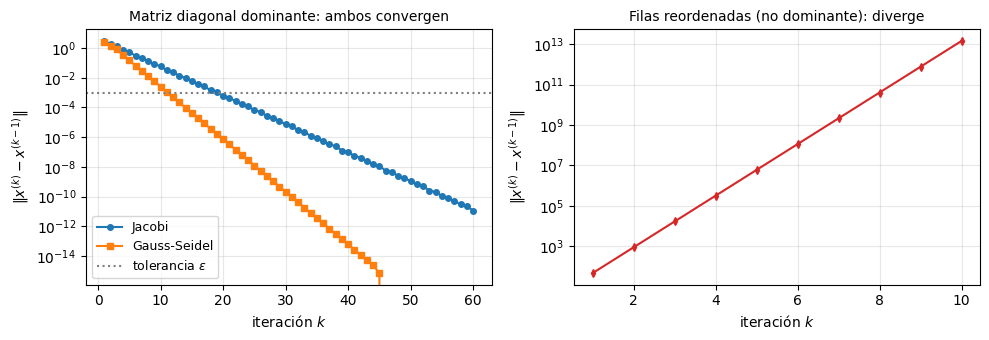

In [36]:
plot_iteration()

Del gráfico de la izquierda concluimos que ambos métodos convergen **linealmente** (recta en escala logarítmica), pero Gauss-Seidel necesita aproximadamente la mitad de las iteraciones.

El panel derecho es el más importante: es **exactamente el mismo sistema de ecuaciones**, solo con las filas escritas en otro orden. Tiene la misma solución, pero Gauss-Seidel diverge. La convergencia no es una propiedad del problema físico, sino **de cómo escribimos la matriz**.

## Solución de sistemas de ecuaciones lineales con python

En python la forma más fácil de resolver un sistema de ecuaciones lineales es mediante la función `solve` de `numpy.linalg`. Esta función utiliza factorización LU con pivoteo parcial (rutina `dgesv` de LAPACK).

Volvamos al problema con el que abrimos el capítulo:

|  Persona   | Masa $[\mathrm{kg}]$ | Constante del resorte $[\mathrm{N/m}]$ | Longitud inicial del elástico $[\mathrm{m}]$ |
|:----------:|:--------:|:--------:|:--------:|
| primera    |60| 50 | 20|
| segunda    |70| 100| 20 |
| tercera    |80|50|20|

Tenemos un sistema de la forma:

$$
\begin{bmatrix}
150 & -100 & 0\\
-100 & 150 & -50\\
0 & -50 & 50\\
\end{bmatrix}\left[\begin{array}{c} x_1 \\x_2 \\x_3 \end{array}\right] =
\left[\begin{array}{c} 588.6 \\686.7 \\784.8\end{array}\right]$$

In [37]:
A = np.array([[ 150., -100.,   0.],
              [-100.,  150., -50.],
              [   0.,  -50.,  50.]])

y = np.array([588.6, 686.7, 784.8])      # y_i = m_i * g

x = np.linalg.solve(A, y)
print('x =', x)

x = [41.202 55.917 71.613]


Antes de confiar en el resultado, verificamos el condicionamiento y el residuo:

In [38]:
print('Cond(A)          = %.2f' % cond(A))
print('residuo relativo = %.2e' % (norm(A.dot(x) - y)/norm(y)))
print('dígitos confiables ~ %.1f' % (16 - np.log10(cond(A))))

Cond(A)          = 21.49
residuo relativo = 1.05e-15
dígitos confiables ~ 14.7


> $\mathrm{Cond}(A) \sim 1\times10^1$: el sistema está muy bien condicionado y la solución es confiable hasta casi la precisión de la máquina.

Notar que en este problema $x_1$, $x_2$ y $x_3$ representan los **desplazamientos** de las personas respecto a la posición sin estirar. La posición final está dada por:

In [39]:
x_inic = np.array([20., 40., 60.])       # posición inicial (elásticos extendidos, sin estirar)
x_final = x + x_inic
print('Desplazamiento de cada cuerpo [m]: ', np.round(x, 3))
print('Posición final de cada cuerpo [m]: ', np.round(x_final, 3))

Desplazamiento de cada cuerpo [m]:  [41.202 55.917 71.613]
Posición final de cada cuerpo [m]:  [ 61.202  95.917 131.613]


Cerremos el problema dibujando el resultado, que era el objetivo desde la primera diapositiva:

<img src="./images/bungee_resultado.png" width="300" align= center>

El tercer cuerpo baja mucho más que el primero, porque **cada elástico soporta el peso de todos los que cuelgan bajo él**. Esa jerarquía es exactamente la que leímos en las columnas de $K^{-1}$.

Para conocer el valor explícito de las matrices $L$, $U$ y $P$, podemos usar la función `lu` de la librería `scipy`.

In [40]:
from scipy.linalg import lu

P, L, U = lu(A)
print('P:\n', P)
print('L:\n', np.round(L, 4))
print('U:\n', np.round(U, 4))
print('P*L*U:\n', np.round(P.dot(L).dot(U), 4))

P:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
L:
 [[ 1.      0.      0.    ]
 [-0.6667  1.      0.    ]
 [ 0.     -0.6     1.    ]]
U:
 [[ 150.     -100.        0.    ]
 [   0.       83.3333  -50.    ]
 [   0.        0.       20.    ]]
P*L*U:
 [[ 150. -100.    0.]
 [-100.  150.  -50.]
 [   0.  -50.   50.]]


> **Ojo con la convención:** `scipy.linalg.lu` devuelve $P$ tal que $A = PLU$, mientras que nosotros escribimos $PA = LU$. Ambas son equivalentes ($P_{scipy} = P^{-1} = P^T$), pero conviene verificar siempre la documentación antes de combinar resultados.

## Resumen: ¿qué método uso?

Ya tenemos varias herramientas. La pregunta práctica es cuál corresponde en cada caso.

Un caso que vale la pena destacar: si $A$ es **tridiagonal** (como la matriz de los elásticos, o las que aparecerán en las unidades de EDO y diferencias finitas), la eliminación de Gauss pasa la mayor parte del tiempo sumando y multiplicando ceros.

Evitando esas operaciones inútiles, la factorización LU de una matriz tridiagonal cuesta solo $O(n)$ en vez de $O(n^3)$. Esa versión especializada se conoce como **algoritmo de Thomas**.

| Situación | Método recomendado | Costo | En python |
|:---|:---|:---|:---|
| Sistema pequeño, un solo $y$ | Eliminación de Gauss / LU | $O(n^3)$ | `np.linalg.solve` |
| Misma $A$, muchos $y$ | LU factorizada una vez | $O(n^3) + k\,O(n^2)$ | `lu_factor` / `lu_solve` |
| $A$ simétrica y definida positiva | Cholesky | $O(n^3/3)$ | `scipy.linalg.cho_factor` |
| $A$ tridiagonal | Thomas (LU especializada) | $O(n)$ | `scipy.linalg.solve_banded` |
| $A$ grande y diagonal dominante | Gauss-Seidel | $O(k\,n^2)$ | implementación propia |
| Interesa la sensibilidad del sistema | Matriz inversa | $O(n^3)$ | `inv` (¡solo para interpretar!) |

Y tres verificaciones que conviene hacer **siempre**, antes de confiar en cualquier resultado:

1. **¿El sistema tiene solución única?** → comparar `matrix_rank(A)` con $n$.
2. **¿Está bien condicionado?** → calcular `cond(A)` y estimar los dígitos confiables como $16 - \log_{10}(\mathrm{Cond}(A))$.
3. **¿El residuo es pequeño?** → evaluar $\|Ax_\mathrm{sol} - y\|/\|y\|$, recordando que un residuo pequeño **no garantiza** un error pequeño si $\mathrm{Cond}(A)$ es grande.

> Y una regla que vale para todo el curso: **nunca resolver un sistema calculando $A^{-1}$**. La inversa sirve para interpretar el problema, no para resolverlo.

## Referencias

- Chapra S., Canale R. **Parte tres: Ecuaciones algebraicas lineales** (Caps. 9–12) en *Métodos Numéricos para Ingenieros*, 6ta Ed., McGraw Hill, 2011.
  - Cap. 9: eliminación de Gauss y pivoteo · Cap. 10: factorización LU y matriz inversa · Cap. 11: matrices especiales (tridiagonales) y Gauss-Seidel

- Press W., Teukolsky S., Vetterling W., Flannery B. **Chapter 2: Solution of Linear Algebraic Equations** in *Numerical Recipes: The Art of Scientific Computing*, 3rd Ed., Cambridge University Press, 2007.
  - §2.4 sistemas tridiagonales y banda · §2.5 refinamiento iterativo · §2.7 sistemas dispersos · §2.11 por qué no invertir la matriz

- Kiusalaas J. **Chapter 2: Systems of Linear Algebraic Equations** in *Numerical Methods in Engineering with Python 3*, 3rd Ed., Cambridge University Press, 2013.
  - Origen de la clasificación Doolittle / Crout / Cholesky

- Kong Q., Siauw T., Bayen A. M. **Chapter 14: Linear Algebra and Systems of Linear Equations** in *[Python Programming and Numerical Methods – A Guide for Engineers and Scientists](https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html)*, 1st Ed., Academic Press, 2021.